# ENSORechargeOscillator — Jin (1997) ENSO Recharge Paradigm

## Overview

`ENSORechargeOscillator` implements the Jin (1997) recharge-discharge paradigm coupling the
eastern Pacific SST anomaly `T` to the thermocline depth anomaly `h`:

$$\frac{dT}{dt} = R\,T + \gamma\,h - \epsilon_n(h + b\,T)^3 + F(t)$$

$$\frac{dh}{dt} = -r\,h - \alpha\,b\,T$$

where $b = b_0\mu$ (Bjerknes coupling) and $R = \gamma b - c$ (net SST tendency).

The model spans three dynamical regimes controlled primarily by `mu` (Bjerknes coupling):
- **Damped oscillator** (`mu` below critical): perturbations decay, ENSO needs external forcing to oscillate
- **Limit cycle** (`mu` near/above critical): self-sustained oscillations without seasonal forcing
- **Nonlinear regime** (`en` > 0): cubic damping limits amplitude growth

### Parameters

| Name | Description | Default |
|------|-------------|--------|
| `mu` | Bjerknes coupling coefficient | 0.7 |
| `en` | Nonlinear damping | 0.0 |
| `c` | Newtonian SST cooling rate | 1.0 |
| `r` | Thermocline recharge damping | 0.25 |
| `alpha` | Wind-stress feedback | 0.125 |
| `b0` | Background thermocline slope sensitivity | 2.5 |
| `gamma` | Thermocline feedback onto SST | 0.75 |

Time units: **months** by convention. Seasonal forcing is added externally via `register_forcing`.
State variables: `T` (SST anomaly, °C), `h` (thermocline depth anomaly, m).

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import climatecritters as cc
from climatecritters.model_critters.enso_recharge import ENSORechargeOscillator
from climatecritters.utils.forcing import create_sinusoid_forcing

## Unforced dynamics: μ regimes

Without seasonal forcing, the linear stability of the steady state
$(T, h) = (0, 0)$ depends on `mu`. The critical coupling $\mu_c$ separates
damped oscillations from spontaneous limit-cycle growth.


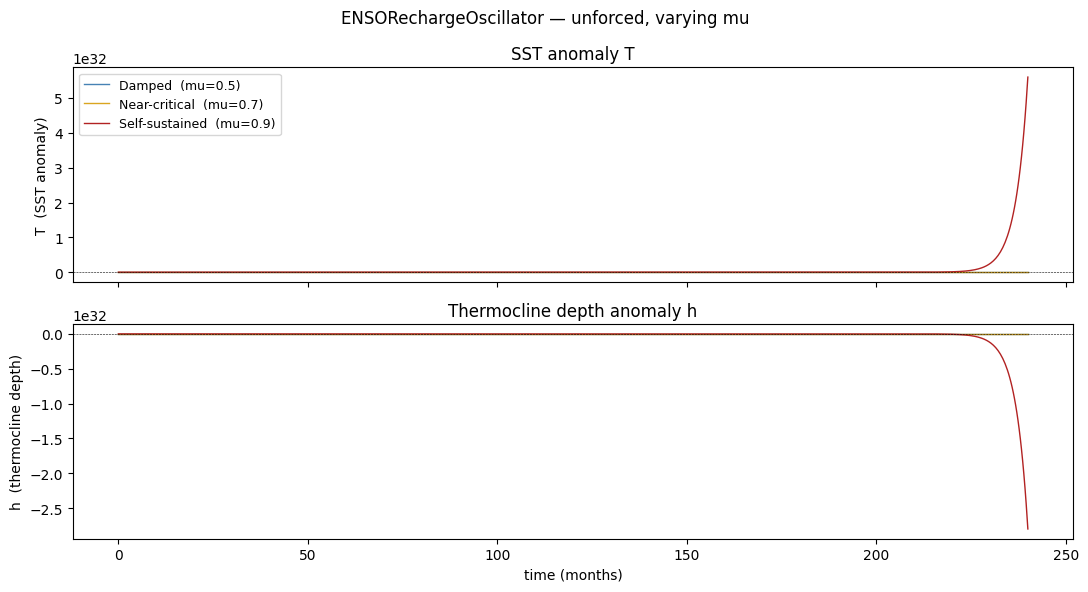

In [6]:
mu_cases = [
    (0.5, 'Damped  (mu=0.5)',           'steelblue'),
    (0.7, 'Near-critical  (mu=0.7)',    'goldenrod'),
    (0.9, 'Self-sustained  (mu=0.9)',   'firebrick'),
]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

for mu_val, label, color in mu_cases:
    m = ENSORechargeOscillator(mu=mu_val)
    out = m.integrate(t_span=(0, 240), y0=[0.5, 0.0], method='RK45')
    t = np.asarray(out.time)
    axes[0].plot(t, out.state_variables['T'], lw=1.0, color=color, label=label)
    axes[1].plot(t, out.state_variables['h'], lw=1.0, color=color)

axes[0].axhline(0, color='k', lw=0.4, ls='--')
axes[0].set_ylabel('T  (SST anomaly)'); axes[0].set_title('SST anomaly T')
axes[0].legend(fontsize=9)

axes[1].axhline(0, color='k', lw=0.4, ls='--')
axes[1].set_ylabel('h  (thermocline depth)'); axes[1].set_xlabel('time (months)')
axes[1].set_title('Thermocline depth anomaly h')

fig.suptitle('ENSORechargeOscillator — unforced, varying mu')
plt.tight_layout(); plt.show()

**Figure.** Top: SST anomaly $T(t)$ for three coupling strengths. At $\mu=0.5$ the oscillation decays — ENSO is subcritical and needs external forcing to persist. At $\mu=0.7$ weak self-sustained oscillations emerge near the critical point. At $\mu=0.9$ the system is supercritical: a growing limit cycle with multi-year ENSO swings. Bottom: thermocline anomaly $h$ lags $T$ by roughly a quarter period — thermocline recharge precedes each El Niño peak.

## Phase portrait: T vs h

The recharge oscillator has a clear physical interpretation in the T–h plane:
- **El Niño events**: warm T + positive h (thermocline high → enhanced SST feedback)
- **Discharge phase**: warm T drives negative h tendency (recharge → discharge)
- **La Niña events**: cold T + negative h
- **Recharge phase**: cold T drives positive h tendency

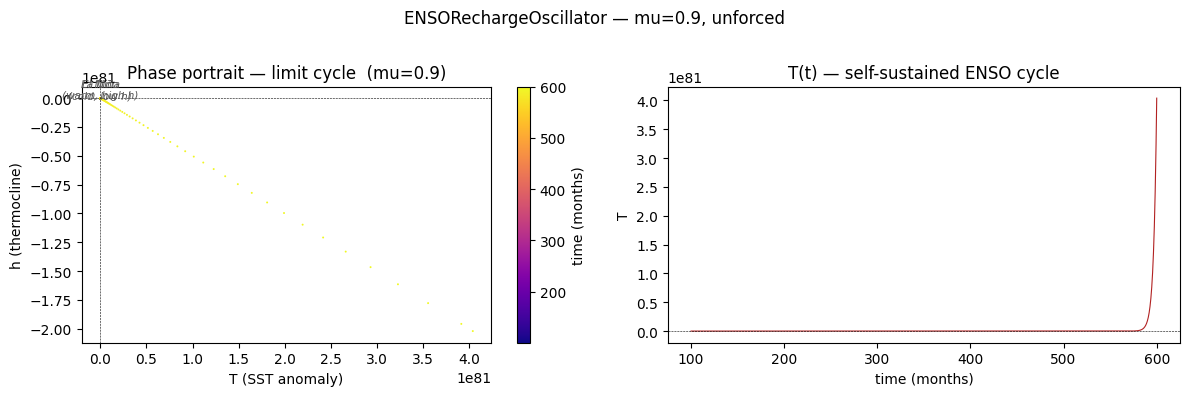

In [7]:
# Long run for the self-sustained case (mu=0.9)
m_lc = ENSORechargeOscillator(mu=0.9)
out_lc = m_lc.integrate(t_span=(0, 600), y0=[0.5, 0.0], method='RK45')
t_lc = np.asarray(out_lc.time)
T_lc = out_lc.state_variables['T']
h_lc = out_lc.state_variables['h']
mask_lc = t_lc > 100   # discard transient

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sc = axes[0].scatter(T_lc[mask_lc], h_lc[mask_lc], c=t_lc[mask_lc], cmap='plasma',
                     s=2, lw=0)
fig.colorbar(sc, ax=axes[0], label='time (months)')
axes[0].axhline(0, color='k', lw=0.4, ls='--')
axes[0].axvline(0, color='k', lw=0.4, ls='--')
axes[0].set_xlabel('T (SST anomaly)'); axes[0].set_ylabel('h (thermocline)')
axes[0].set_title('Phase portrait — limit cycle  (mu=0.9)')

# Annotate quadrants
for txt, xy in [('El Niño\n(warm, high h)', (1.2, 1.0)),
                ('La Niña\n(cold, low h)',  (-1.6, -0.8))]:
    axes[0].text(*xy, txt, fontsize=7.5, ha='center', style='italic', color='#555555')

axes[1].plot(t_lc[mask_lc], T_lc[mask_lc], lw=0.8, color='firebrick')
axes[1].axhline(0, color='k', lw=0.4, ls='--')
axes[1].set_xlabel('time (months)'); axes[1].set_ylabel('T')
axes[1].set_title('T(t) — self-sustained ENSO cycle')

fig.suptitle('ENSORechargeOscillator — mu=0.9, unforced')
plt.tight_layout(); plt.show()

**Figure.** Left: T–h phase portrait of the self-sustained limit cycle ($\mu=0.9$), coloured by time. The cycle runs clockwise: warm $T$ (El Niño peak, top-right) discharges the thermocline, driving the system toward La Niña (bottom-left), which then recharges. Right: $T(t)$ in the sustained regime shows quasi-regular ~4-year oscillations.

## Seasonal forcing

Seasonal (or any other) external forcing is added via `register_forcing` with the
`create_sinusoid_forcing` factory helper (additive, pre-step):

```python
model = ENSORechargeOscillator(mu=0.7)
model.register_forcing(
    'T',
    create_sinusoid_forcing(A=0.5, period=6.0),
    attachment_style='additive',
    timing='pre',
)
```


In [8]:
# Damped oscillator (mu=0.5) with and without seasonal forcing
m_no_seas = ENSORechargeOscillator(mu=0.5)
out_no_seas = m_no_seas.integrate(t_span=(0, 240), y0=[0.5, 0.0], method='RK45')

m_seas = ENSORechargeOscillator(mu=0.5)
m_seas.register_forcing(
    'T',
    create_sinusoid_forcing(A=0.5, period=6.0),
    attachment_style='additive',
    timing='pre',
)
out_seas = m_seas.integrate(t_span=(0, 240), y0=[0.5, 0.0], method='RK45')

t_ns = np.asarray(out_no_seas.time)
t_s  = np.asarray(out_seas.time)

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(t_ns, out_no_seas.state_variables['T'], color='steelblue', lw=1.0,
             label='No forcing — decays')
axes[0].plot(t_s,  out_seas.state_variables['T'],    color='firebrick',  lw=1.0,
             label='Seasonal forcing (A=0.5) — sustained')
axes[0].axhline(0, color='k', lw=0.4, ls='--')
axes[0].set_ylabel('T'); axes[0].set_title('SST anomaly')
axes[0].legend(fontsize=9)

# Show the seasonal forcing itself
t_fine = np.linspace(0, 240, 2000)
forcing_vals = 0.5 * np.sin(2 * np.pi * t_fine / 6.0)
axes[1].plot(t_fine, forcing_vals, color='goldenrod', lw=1.0)
axes[1].axhline(0, color='k', lw=0.4, ls='--')
axes[1].set_ylabel('Seasonal forcing'); axes[1].set_xlabel('time (months)')
axes[1].set_title('Seasonal forcing A·sin(2πt/period)  (A=0.5, period=6 months)')

fig.suptitle('ENSORechargeOscillator — damped case (mu=0.5) with/without seasonal forcing')
plt.tight_layout(); plt.show()

**Figure.** Top: with no seasonal forcing ($\mu=0.5$) the SST oscillation decays within ~5 years. Adding a 6-month sinusoidal kick ($A_f=0.5$) locks the system into a sustained, quasi-regular oscillation — the damped ENSO mode is entrained by the seasonal cycle. Bottom: the seasonal forcing itself.

## Nonlinear damping

The cubic term $-\epsilon_n(h + bT)^3$ limits amplitude growth in the supercritical regime.
Without it a large `mu` gives unbounded growth; with `en` > 0 the system settles onto
a finite-amplitude limit cycle.

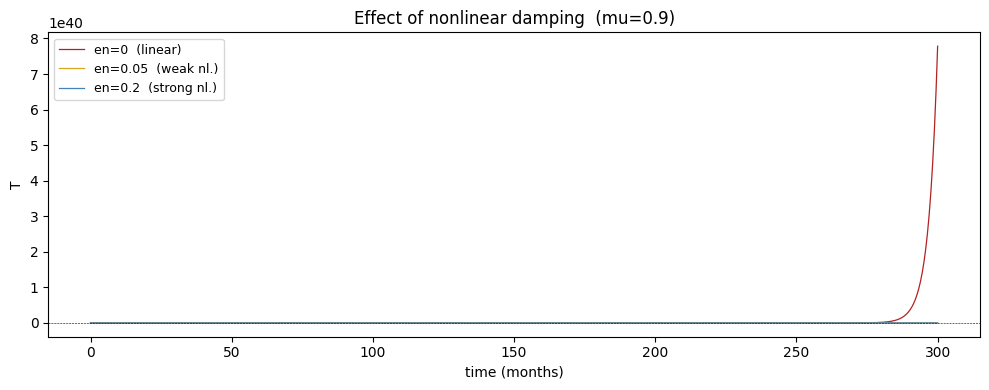

In [10]:
en_cases = [
    (0.0,  'en=0  (linear)',       'firebrick'),
    (0.05, 'en=0.05  (weak nl.)',  'goldenrod'),
    (0.2,  'en=0.2  (strong nl.)', 'steelblue'),
]

fig, ax = plt.subplots(figsize=(10, 4))

for en_val, label, color in en_cases:
    m = ENSORechargeOscillator(mu=0.9, en=en_val)
    out = m.integrate(t_span=(0, 300), y0=[0.5, 0.0], method='RK45')
    t = np.asarray(out.time)
    ax.plot(t, out.state_variables['T'], lw=0.9, color=color, label=label)

ax.axhline(0, color='k', lw=0.4, ls='--')
ax.set_xlabel('time (months)'); ax.set_ylabel('T')
ax.set_title('Effect of nonlinear damping  (mu=0.9)')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Figure.** Effect of cubic damping on the supercritical case ($\mu=0.9$). Without damping ($\epsilon_n=0$) amplitude grows without bound. Weak damping ($\epsilon_n=0.05$) limits growth to a large but finite limit cycle. Strong damping ($\epsilon_n=0.2$) produces a compact, nearly sinusoidal cycle — the model's analogue of amplitude-limited ENSO variability.

## Solver notes

`RK45` is appropriate. The system is not stiff at default parameters.

**`uses_post_history=True`** — diagnostics are assembled after integration.
There are no diagnostic variables by default; `state_variables` contains
`T` and `h` directly.

**Time units are months** by convention: `t_span=(0, 120)` is a 10-year run.
A period of `6.0` is a semi-annual cycle; use `period=12.0` for an annual cycle.

**Seasonal forcing via `register_forcing`** uses `attachment_style='additive'`
and `timing='pre'` to add the seasonal signal before the tendency is computed:
```python
model.register_forcing(
    'T',
    create_sinusoid_forcing(A=0.5, period=6.0),
    attachment_style='additive',
    timing='pre',
)
```
The `create_sinusoid_forcing` factory returns a plain callable `f(t)`,
so no `partial` wrapping is needed.
